In [ ]:
!pip install transformers datasets scikit-learn lime \
           imbalanced-learn matplotlib seaborn --quiet

import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

In [12]:
import pandas as pd

archivos = ['Enron.csv', 'Nazario_5.csv', 'SpamAssasin.csv']
dfs = {}

for nombre in archivos:
    path = f"{base}/{nombre}"
    df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
    dfs[nombre] = df
    print(f"\n{'='*50}")
    print(f"📄 {nombre}")
    print(f"   Filas: {len(df):,}")
    print(f"   Columnas: {list(df.columns)}")
    print(f"   Nulos: {df.isnull().sum().to_dict()}")
    if 'label' in df.columns:
        print(f"   Etiquetas: {df['label'].value_counts().to_dict()}")


📄 Enron.csv
   Filas: 29,767
   Columnas: ['subject', 'body', 'label']
   Nulos: {'subject': 198, 'body': 0, 'label': 0}
   Etiquetas: {0: 15791, 1: 13976}

📄 Nazario_5.csv
   Filas: 3,065
   Columnas: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
   Nulos: {'sender': 2, 'receiver': 113, 'date': 3, 'subject': 50, 'body': 0, 'label': 0, 'urls': 0}
   Etiquetas: {1: 1565, 0: 1500}

📄 SpamAssasin.csv
   Filas: 5,809
   Columnas: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
   Nulos: {'sender': 0, 'receiver': 210, 'date': 0, 'subject': 16, 'body': 1, 'label': 0, 'urls': 0}
   Etiquetas: {0: 4091, 1: 1718}


In [13]:
COL_TEXTO = 'body'
COL_LABEL = 'label'

fragmentos = []
for nombre, df in dfs.items():
    # Combinar subject + body para tener más contexto
    df = df.copy()
    df['subject'] = df['subject'].fillna('') if 'subject' in df.columns else ''
    df['text'] = df['subject'].astype(str) + ' ' + df['body'].astype(str)
    df['label'] = df[COL_LABEL]
    df['source'] = nombre
    fragmentos.append(df[['text', 'label', 'source']])

dataset = pd.concat(fragmentos, ignore_index=True)
dataset = dataset.dropna(subset=['text', 'label'])
dataset['text'] = dataset['text'].astype(str).str.strip()
dataset = dataset[dataset['text'].str.len() > 20]

# Normalizar etiquetas a 0/1 por si acaso
dataset['label'] = dataset['label'].astype(int)

print(f"Total muestras: {len(dataset):,}")
print(f"\nDistribución:")
print(dataset['label'].value_counts())
print(f"\nPor fuente:")
print(dataset['source'].value_counts())

Total muestras: 38,630

Distribución:
label
0    21379
1    17251
Name: count, dtype: int64

Por fuente:
source
Enron.csv          29756
SpamAssasin.csv     5809
Nazario_5.csv       3065
Name: count, dtype: int64


In [14]:
#Guardar el dataset unificado
output_path = '/content/drive/MyDrive/TFG_Phishing/datasets/dataset_unificado.csv'
dataset.to_csv(output_path, index=False)
print(f"✓ Guardado en Drive: {output_path}")
print(f"  Tamaño: {os.path.getsize(output_path)/1e6:.1f} MB")

✓ Guardado en Drive: /content/drive/MyDrive/TFG_Phishing/datasets/dataset_unificado.csv
  Tamaño: 70.6 MB


Train: 30,904  |  Test: 7,726
Vocabulario TF-IDF: 20,000 tokens

Entrenando Logistic Regression...
  Accuracy:  0.9841
  Precision: 0.9829
  Recall:    0.9814
  F1-score:  0.9822
  ROC-AUC:   0.9984

Entrenando Random Forest...
  Accuracy:  0.9789
  Precision: 0.9727
  Recall:    0.9803
  F1-score:  0.9765
  ROC-AUC:   0.9973

Entrenando XGBoost...
  Accuracy:  0.9735
  Precision: 0.9611
  Recall:    0.9803
  F1-score:  0.9706
  ROC-AUC:   0.9970


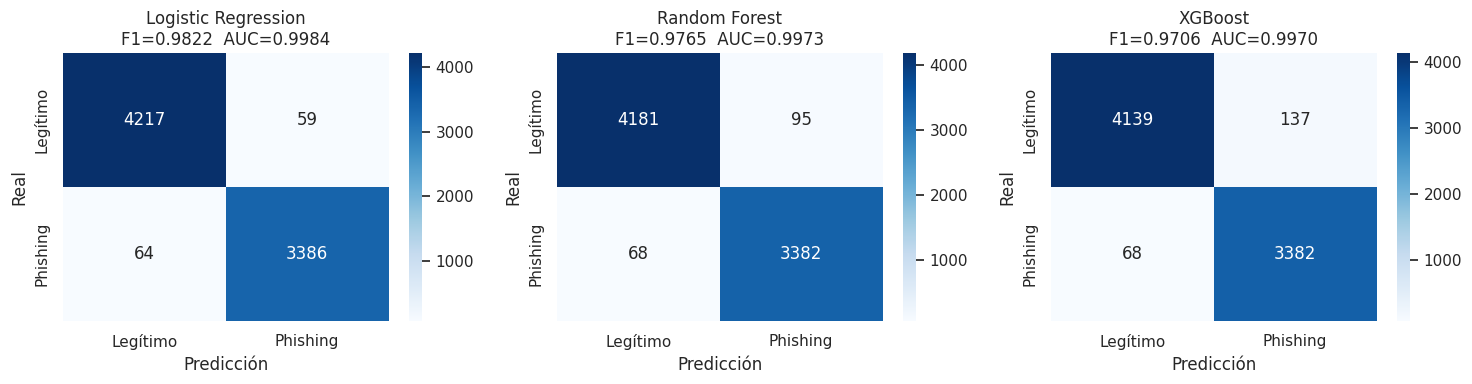


✓ Gráfico guardado en Drive


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Split ──────────────────────────────────────────────────────────────────
X = dataset['text'].values
y = dataset['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── TF-IDF ─────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=20000, sublinear_tf=True,
                        ngram_range=(1, 2), min_df=2)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)
print(f"Vocabulario TF-IDF: {len(tfidf.vocabulary_):,} tokens")

# ── Modelos baseline ───────────────────────────────────────────────────────
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                         eval_metric='logloss', random_state=42)
}

resultados = {}
for nombre, modelo in modelos.items():
    print(f"\nEntrenando {nombre}...")
    modelo.fit(X_train_tf, y_train)
    y_pred = modelo.predict(X_test_tf)
    y_prob = modelo.predict_proba(X_test_tf)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc    = roc_auc_score(y_test, y_prob)

    resultados[nombre] = {
        'accuracy':  report['accuracy'],
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score'],
        'auc':       auc,
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    print(f"  Accuracy:  {report['accuracy']:.4f}")
    print(f"  Precision: {report['1']['precision']:.4f}")
    print(f"  Recall:    {report['1']['recall']:.4f}")
    print(f"  F1-score:  {report['1']['f1-score']:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")

# ── Matrices de confusión ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legítimo', 'Phishing'],
                yticklabels=['Legítimo', 'Phishing'])
    ax.set_title(f"{nombre}\nF1={res['f1']:.4f}  AUC={res['auc']:.4f}")
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG_Phishing/baseline_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Gráfico guardado en Drive")

/tmp/ipykernel_3436/2683822978.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3436/2683822978.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


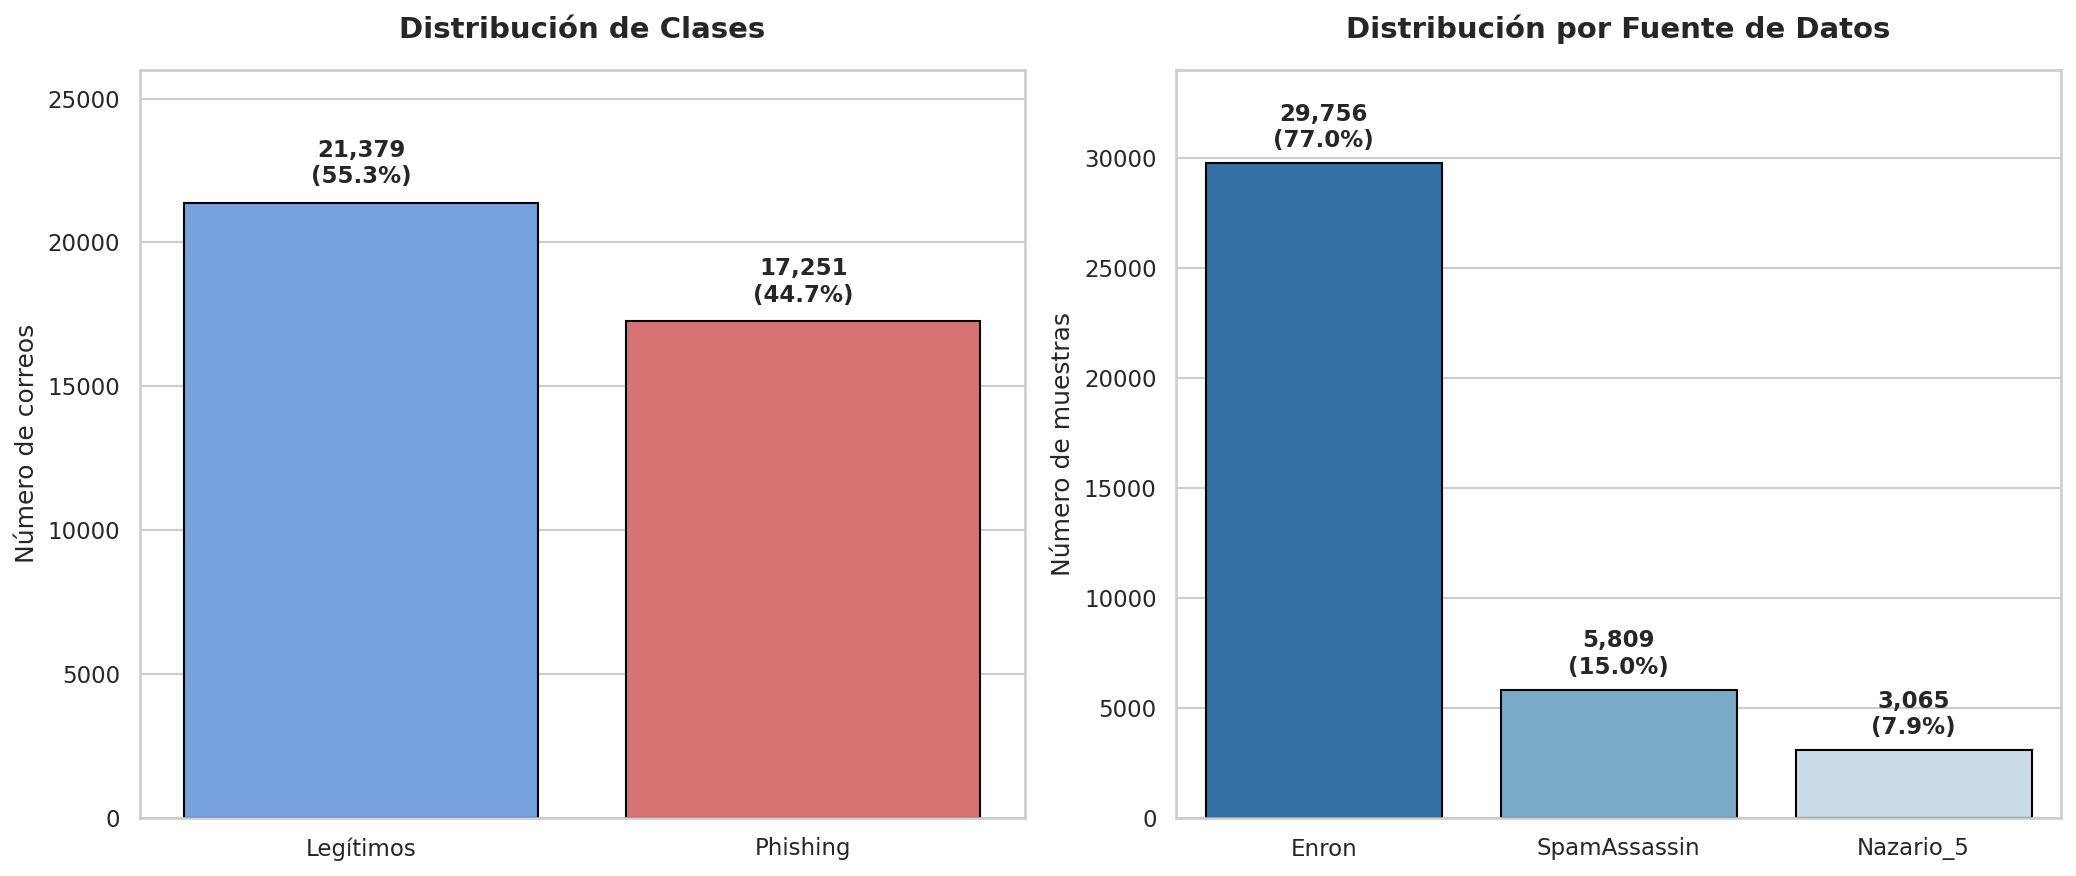

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definición de los datos
total_muestras = 38630

# Datos de clases (0: Legítimos, 1: Phishing)
clases_labels = ['Legítimos', 'Phishing']
clases_counts  = [21379, 17251]

# Datos de fuentes
fuentes_labels = ['Enron', 'SpamAssassin', 'Nazario_5']
fuentes_counts = [29756, 5809, 3065]

# 2. Configuración general del estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# --- Gráfico 1: Distribución de Clases ---
# Usamos colores similares a tu imagen (azul claro y rojo apagado)
sns.barplot(
    x=clases_labels,
    y=clases_counts,
    ax=axes[0],
    palette=['#659CEF', '#E66363'],
    edgecolor='black'
)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Número de correos', fontsize=12)
axes[0].set_ylim(0, 26000) # Límite para dejar espacio a los textos

# Añadir textos (cantidad y porcentaje) en las barras
for i, count in enumerate(clases_counts):
    pct = (count / total_muestras) * 100
    axes[0].text(
        i, count + 500,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# --- Gráfico 2: Distribución por Fuente de Datos ---
# Usamos una paleta de azules en degradado
sns.barplot(
    x=fuentes_labels,
    y=fuentes_counts,
    ax=axes[1],
    palette='Blues_r',
    edgecolor='black'
)
axes[1].set_title('Distribución por Fuente de Datos', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Número de muestras', fontsize=12)
axes[1].set_ylim(0, 34000)

# Añadir textos (cantidad y porcentaje) en las barras
for i, count in enumerate(fuentes_counts):
    pct = (count / total_muestras) * 100
    axes[1].text(
        i, count + 500,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Ajuste de layout y renderizado
plt.tight_layout()
plt.show()

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# ── 1. Estadísticas de longitud ───────────────────────────────────────────
dataset['longitud'] = dataset['text'].str.len()
dataset['n_palabras'] = dataset['text'].str.split().str.len()

print("=== LONGITUD EN CARACTERES ===")
print(dataset.groupby('label')['longitud'].describe().round(1).to_string())
print("\n=== NÚMERO DE PALABRAS ===")
print(dataset.groupby('label')['n_palabras'].describe().round(1).to_string())

# ── 2. Top 20 palabras por clase ──────────────────────────────────────────
stopwords = {'the','to','a','of','and','in','is','you','your','i','it',
             'for','on','this','we','are','be','with','that','have',
             'an','at','as','not','our','will','us','or','if','from',
             'has','by','do','all','my','me','please','hi','hello','dear',
             'nbsp','http','com','www','re','fw','subject'}

def top_words(df, label, n=20):
    texts = df[df['label']==label]['text'].str.lower()
    words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts))
    filtered = [w for w in words if w not in stopwords]
    return Counter(filtered).most_common(n)

print("\n=== TOP 20 PALABRAS — PHISHING (label=1) ===")
for w, c in top_words(dataset, 1):
    print(f"  {w}: {c:,}")

print("\n=== TOP 20 PALABRAS — LEGÍTIMO (label=0) ===")
for w, c in top_words(dataset, 0):
    print(f"  {w}: {c:,}")

# ── 3. Distribución por fuente ────────────────────────────────────────────
print("\n=== DISTRIBUCIÓN POR FUENTE Y CLASE ===")
print(dataset.groupby(['source','label']).size().unstack(fill_value=0).to_string())

# ── 4. Percentiles de longitud útiles para truncado en DistilBERT ─────────
print("\n=== PERCENTILES DE LONGITUD (palabras) ===")
percentiles = dataset['n_palabras'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])
print(percentiles.round(0).to_string())
print(f"  Textos con >512 palabras: {(dataset['n_palabras']>512).sum():,} "
      f"({(dataset['n_palabras']>512).mean()*100:.1f}%)")

=== LONGITUD EN CARACTERES ===
         count    mean      std   min    25%    50%     75%        max
label                                                                 
0      21379.0  1769.7   5697.3  22.0  398.0  879.0  1732.5   299272.0
1      17251.0  1853.9  36047.0  21.0  392.0  738.0  1552.0  4599694.0

=== NÚMERO DE PALABRAS ===
         count   mean     std  min   25%    50%    75%       max
label                                                           
0      21379.0  335.0   981.8  4.0  77.0  169.0  348.0   45450.0
1      17251.0  277.6  1109.2  2.0  74.0  140.0  280.0  127127.0

=== TOP 20 PALABRAS — PHISHING (label=1) ===
  email: 12,863
  can: 10,387
  company: 10,229
  here: 9,590
  information: 9,414
  net: 9,381
  more: 8,869
  any: 8,703
  account: 8,430
  mail: 8,169
  hotmail: 7,650
  get: 6,845
  out: 6,760
  one: 6,745
  may: 6,744
  free: 6,700
  aol: 6,689
  now: 6,652
  only: 6,491
  new: 6,387

=== TOP 20 PALABRAS — LEGÍTIMO (label=0) ===
  enron: 54,261

In [ ]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

print(f"PyTorch: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("\nDescargando tokenizador...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-multilingual-cased')
print(f"✓ Tokenizador listo. Vocabulario: {tokenizer.vocab_size:,} tokens")

In [26]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch

base = '/content/drive/MyDrive/TFG_Phishing/datasets'
dataset = pd.read_csv(f'{base}/dataset_unificado_v2.csv')
print(f"✓ Corpus v2 cargado: {len(dataset):,} muestras")

X = dataset['text'].values
y = dataset['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Tokenización dinámica — evita el error de RAM
class PhishingDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=256,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = PhishingDataset(X_train, y_train)
test_dataset  = PhishingDataset(X_test,  y_test)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Batches por época: {len(train_loader):,}")

✓ Corpus v2 cargado: 38,630 muestras
Train: 30,904 | Test: 7,726
Batches por época: 966


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import torch, os
from transformers import DistilBertTokenizerFast
print(f"GPU: {torch.cuda.get_device_name(0)}")

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-multilingual-cased')
print("✓ Tokenizador listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
✓ Tokenizador listo


In [27]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

base = '/content/drive/MyDrive/TFG_Phishing/datasets'
dataset_df = pd.read_csv(f'{base}/dataset_unificado_v2.csv')

X = dataset_df['text'].values
y = dataset_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

class PhishingDataset(Dataset):
    def __init__(self, texts, labels):
        # Solo guarda los textos y etiquetas en bruto
        # NO tokeniza aquí — lo hace en __getitem__ por batch
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Tokenización dinámica: solo el ejemplo que se necesita ahora
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=256,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = PhishingDataset(X_train, y_train)
test_dataset  = PhishingDataset(X_test,  y_test)

# num_workers=2 para paralelizar la tokenización dinámica
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"✓ Datasets listos (tokenización dinámica, sin carga masiva en RAM)")
print(f"Batches por época: {len(train_loader):,}")

Train: 30,904 | Test: 7,726
✓ Datasets listos (tokenización dinámica, sin carga masiva en RAM)
Batches por época: 966


In [ ]:
!pip install lime --quiet
print("✓ LIME instalado")

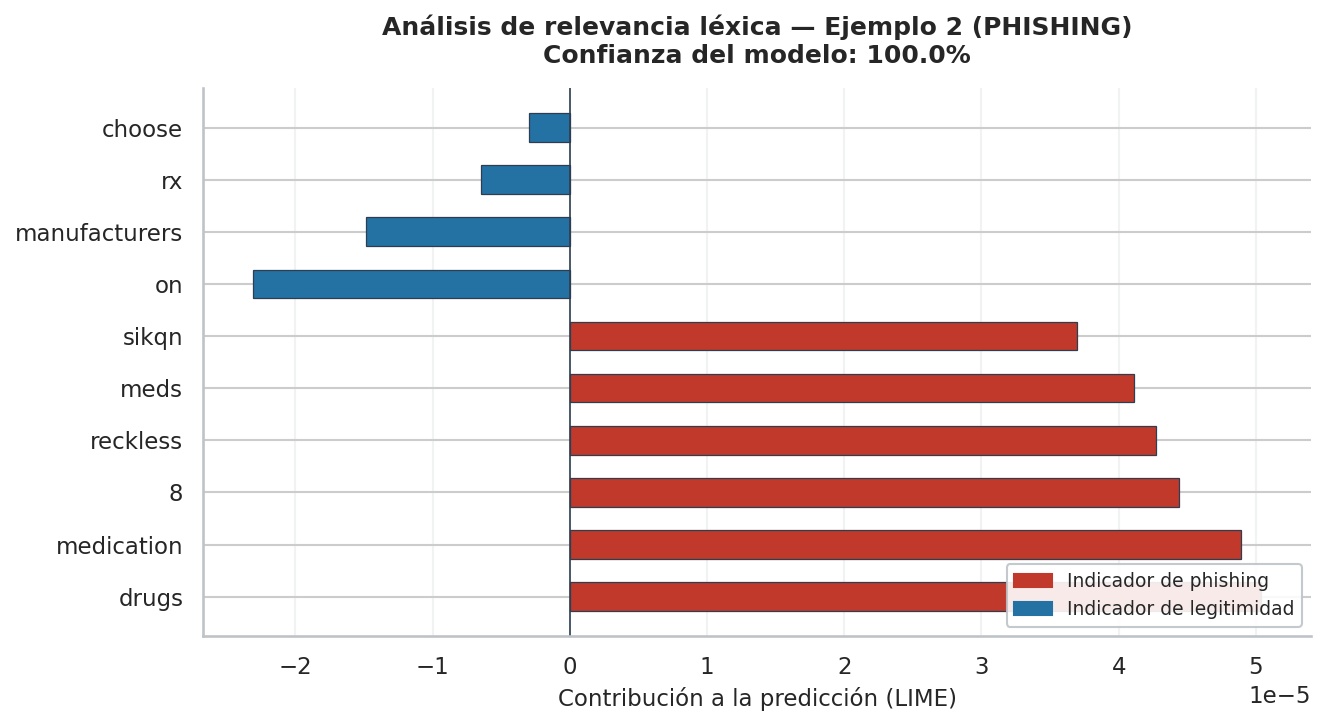

✓ Guardado: /content/drive/MyDrive/TFG_Phishing/lime_explicaciones/lime_final_ejemplo_2.png
  drugs                +0.0001  → PHISHING
  medication           +0.0000  → PHISHING
  8                    +0.0000  → PHISHING
  reckless             +0.0000  → PHISHING
  meds                 +0.0000  → PHISHING
  sikqn                +0.0000  → PHISHING


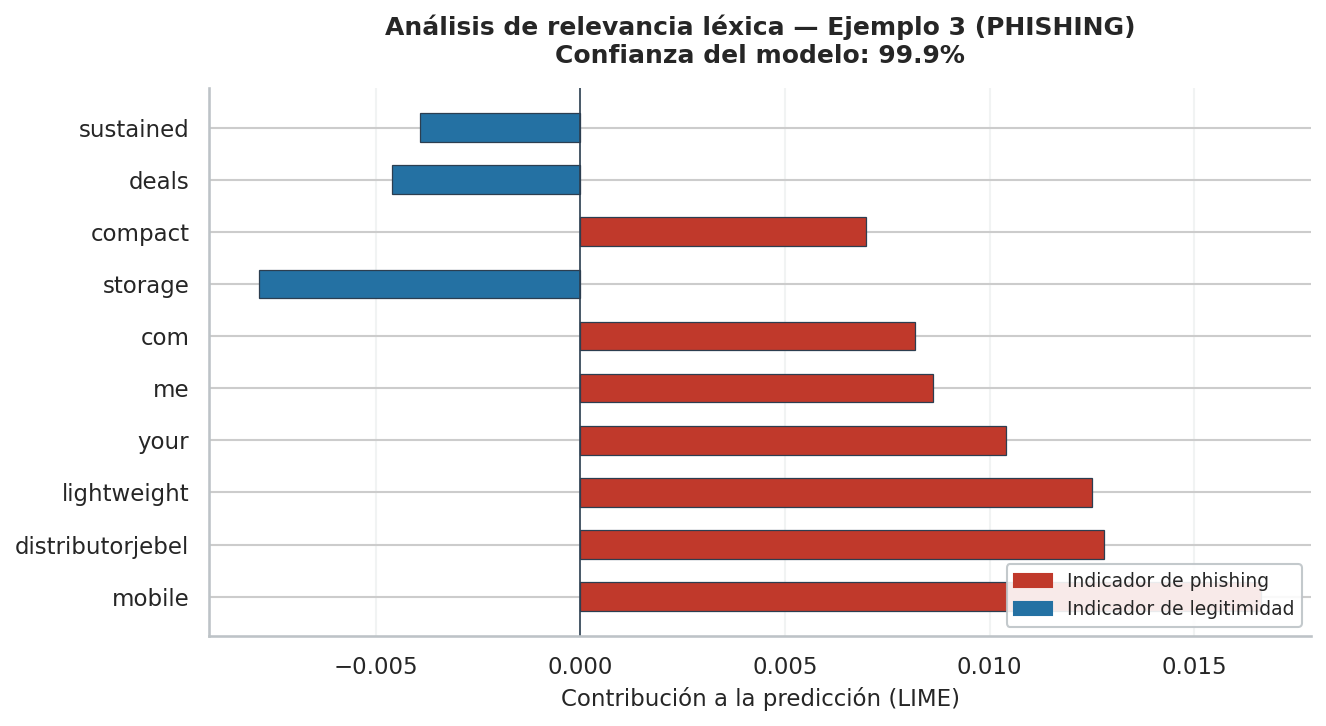

✓ Guardado: /content/drive/MyDrive/TFG_Phishing/lime_explicaciones/lime_final_ejemplo_3.png
  mobile               +0.0166  → PHISHING
  distributorjebel     +0.0128  → PHISHING
  lightweight          +0.0125  → PHISHING
  your                 +0.0104  → PHISHING
  me                   +0.0086  → PHISHING
  com                  +0.0082  → PHISHING


In [28]:
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ── Cargar test set del corpus v2 ─────────────────────────────────────────
base = '/content/drive/MyDrive/TFG_Phishing/datasets'
dataset_df = pd.read_csv(f'{base}/dataset_unificado_v2.csv')
_, X_test, _, y_test = train_test_split(
    dataset_df['text'].values, dataset_df['label'].values,
    test_size=0.2, random_state=42, stratify=dataset_df['label'].values
)

# ── Seleccionar ejemplos phishing bien clasificados ────────────────────────
explainer  = LimeTextExplainer(class_names=['Legítimo', 'Phishing'], random_state=42)
encontrados = []

for i in range(len(X_test)):
    if len(encontrados) >= 3:
        break
    texto = X_test[i][:1000]
    proba = predecir_proba_demo([texto])[0]
    if np.argmax(proba) == 1 and y_test[i] == 1:
        encontrados.append((texto, proba[1]))

# ── Generar figuras definitivas (ejemplos 2 y 3) ─────────────────────────
for idx_rel, (idx_fig, (texto, confianza)) in enumerate(
        zip([2, 3], encontrados[1:3])):

    exp      = explainer.explain_instance(
        texto, predecir_proba_demo,
        num_features=10, num_samples=1000, labels=[1])
    palabras = exp.as_list(label=1)
    terminos = [p[0] for p in palabras]
    pesos    = [p[1] for p in palabras]
    colores  = ['#C0392B' if p > 0 else '#2471A3' for p in pesos]

    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.barh(range(len(terminos)), pesos, color=colores,
            edgecolor='#2C3E50', height=0.55, linewidth=0.6)
    ax.set_yticks(range(len(terminos)))
    ax.set_yticklabels(terminos, fontsize=11)
    ax.axvline(x=0, color='#2C3E50', linewidth=0.8)
    ax.set_xlabel('Contribución a la predicción (LIME)', fontsize=11)
    ax.set_title(
        f'Análisis de relevancia léxica — Ejemplo {idx_fig} (PHISHING)\n'
        f'Confianza del modelo: {confianza:.1%}',
        fontsize=12, fontweight='bold', pad=12)
    rojo = mpatches.Patch(color='#C0392B', label='Indicador de phishing')
    azul = mpatches.Patch(color='#2471A3', label='Indicador de legitimidad')
    ax.legend(handles=[rojo, azul], fontsize=9, loc='lower right',
              framealpha=0.9, edgecolor='#BDC3C7')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#BDC3C7')
    ax.spines['bottom'].set_color('#BDC3C7')
    ax.grid(True, axis='x', alpha=0.2, color='#BDC3C7')
    plt.tight_layout()

    ruta = f"/content/drive/MyDrive/TFG_Phishing/lime_explicaciones/lime_final_ejemplo_{idx_fig}.png"
    plt.savefig(ruta, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print(f"✓ Guardado: {ruta}")
    for palabra, peso in palabras[:6]:
        print(f"  {palabra:20} {peso:+.4f}  → {'PHISHING' if peso > 0 else 'LEGÍTIMO'}")

In [ ]:
!pip install gradio --quiet
print("✓ Gradio instalado")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ Modelo v2 (fpr_optimo) cargado
✓ Test set v2: 7,726 muestras
Evaluando sobre test set v2...
  Procesados 1,280/7,726
  Procesados 2,560/7,726
  Procesados 3,840/7,726
  Procesados 5,120/7,726
  Procesados 6,400/7,726
  Procesados 7,680/7,726
✓ Evaluación completada

  Umbral       F1      FPR      FNR
  0.30   0.9856   0.0075   0.0194
  0.35   0.9859   0.0063   0.0203
  0.40   0.9858   0.0058   0.0209
  0.45   0.9853   0.0058   0.0220
  0.50   0.9850   0.0058   0.0226 ← seleccionado
  0.55   0.9848   0.0056   0.0232
  0.60   0.9847   0.0056   0.0235
  0.65   0.9841   0.0054   0.0249
  0.70   0.9839   0.0051   0.0255
  0.75   0.9836   0.0051   0.0261
  0.80   0.9832   0.0049   0.0272
  0.85   0.9827   0.0049   0.0281
  0.90   0.9814   0.0044   0.0313


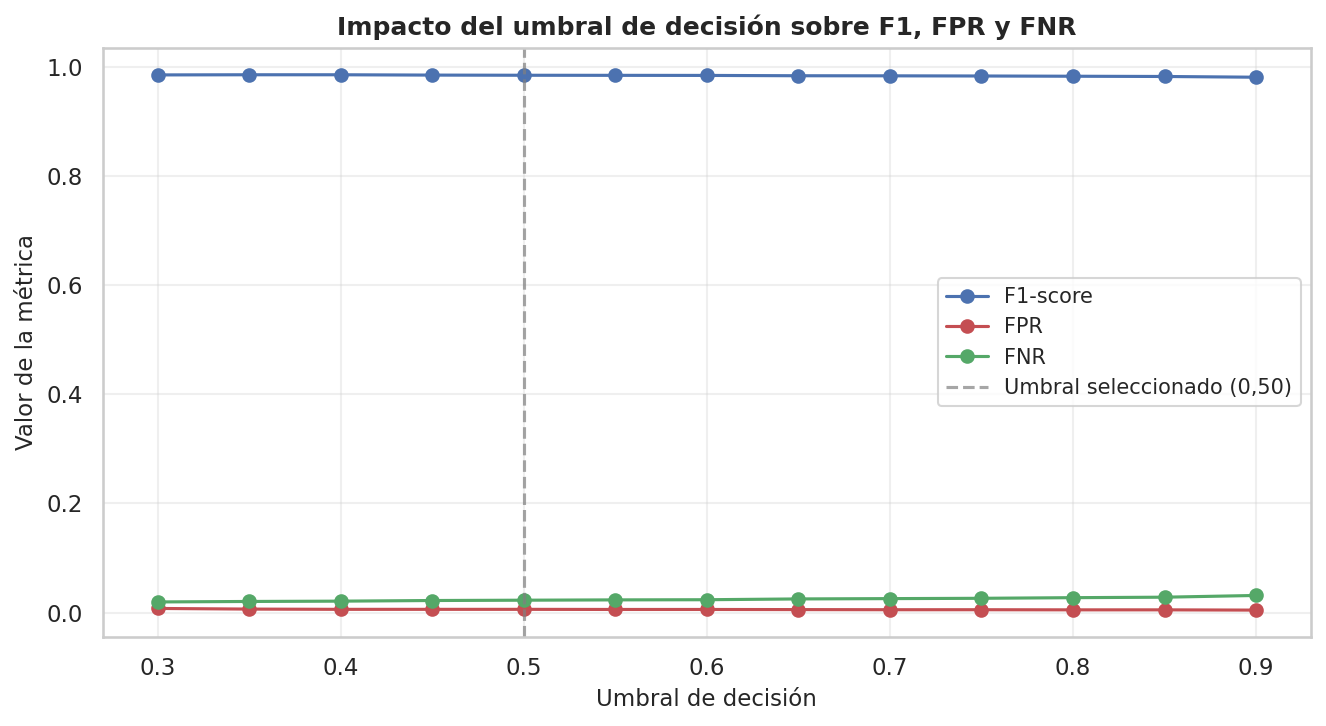


✓ Guardado: analisis_umbral_v2.png


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

# ── Cargar modelo v2 ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_DIR = '/content/drive/MyDrive/TFG_Phishing/models_v2'

model_umbral     = DistilBertForSequenceClassification.from_pretrained(
    f"{CHECKPOINT_DIR}/distilbert_fpr_optimo")
tokenizer_umbral = DistilBertTokenizerFast.from_pretrained(
    f"{CHECKPOINT_DIR}/distilbert_fpr_optimo")
model_umbral.to(device)
model_umbral.eval()
print("✓ Modelo v2 (fpr_optimo) cargado")

# ── Reconstruir test set corpus v2 ────────────────────────────────────────
base       = '/content/drive/MyDrive/TFG_Phishing/datasets'
dataset_df = pd.read_csv(f'{base}/dataset_unificado_v2.csv')
_, X_test, _, y_test = train_test_split(
    dataset_df['text'].values, dataset_df['label'].values,
    test_size=0.2, random_state=42, stratify=dataset_df['label'].values
)
print(f"✓ Test set v2: {len(X_test):,} muestras")

# ── Evaluar sobre test set ─────────────────────────────────────────────────
print("Evaluando sobre test set v2...")
all_probs  = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(X_test), 64):
        batch_texts  = list(X_test[i:i+64])
        batch_labels = list(y_test[i:i+64])
        enc = tokenizer_umbral(
            batch_texts, truncation=True, padding=True,
            max_length=256, return_tensors='pt'
        )
        outputs = model_umbral(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        )
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(batch_labels)

        if (i // 64 + 1) % 20 == 0:
            print(f"  Procesados {min(i+64, len(X_test)):,}/{len(X_test):,}")

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
print("✓ Evaluación completada")

# ── Análisis de umbrales ───────────────────────────────────────────────────
umbrales = np.arange(0.3, 0.95, 0.05)
resultados_umbral = []

for u in umbrales:
    preds = (all_probs >= u).astype(int)
    f1    = f1_score(all_labels, preds)
    cm    = confusion_matrix(all_labels, preds)
    fpr   = cm[0,1] / (cm[0,1] + cm[0,0]) if (cm[0,1] + cm[0,0]) > 0 else 0
    fnr   = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    resultados_umbral.append({'umbral': u, 'f1': f1, 'fpr': fpr, 'fnr': fnr})

print(f"\n{'Umbral':>8} {'F1':>8} {'FPR':>8} {'FNR':>8}")
print("="*36)
for r in resultados_umbral:
    marca = " ← seleccionado" if abs(r['umbral'] - 0.5) < 0.01 else ""
    print(f"  {r['umbral']:.2f}   {r['f1']:.4f}   {r['fpr']:.4f}   {r['fnr']:.4f}{marca}")

# ── Gráfico ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
ax.plot([r['umbral'] for r in resultados_umbral],
        [r['f1']     for r in resultados_umbral], 'b-o', label='F1-score')
ax.plot([r['umbral'] for r in resultados_umbral],
        [r['fpr']    for r in resultados_umbral], 'r-o', label='FPR')
ax.plot([r['umbral'] for r in resultados_umbral],
        [r['fnr']    for r in resultados_umbral], 'g-o', label='FNR')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7,
           label='Umbral seleccionado (0,50)')
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Impacto del umbral de decisión sobre F1, FPR y FNR',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG_Phishing/analisis_umbral_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Guardado: analisis_umbral_v2.png")

In [ ]:
import pandas as pd

base = '/content/drive/MyDrive/TFG_Phishing/datasets'

nazario    = pd.read_csv(f'{base}/Nazario.csv', encoding='utf-8', on_bad_lines='skip')
nazario_5  = pd.read_csv(f'{base}/Nazario_5.csv', encoding='utf-8', on_bad_lines='skip')

# Comparar cuerpos de los correos phishing de ambos datasets
nazario_bodies   = set(nazario['body'].astype(str).str.strip())
nazario5_phish   = set(nazario_5[nazario_5['label']==1]['body'].astype(str).str.strip())

duplicados = nazario_bodies.intersection(nazario5_phish)

print(f"Correos en Nazario.csv:              {len(nazario_bodies):,}")
print(f"Correos phishing en Nazario_5.csv:   {len(nazario5_phish):,}")
print(f"Duplicados exactos encontrados:      {len(duplicados):,}")
print(f"Porcentaje solapamiento:             {len(duplicados)/len(nazario_bodies)*100:.1f}%")

In [30]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

base = '/content/drive/MyDrive/TFG_Phishing/datasets'

# Cargar solo los tres datasets no duplicados
archivos = ['Enron.csv', 'Nazario_5.csv', 'SpamAssasin.csv']
fragmentos = []

for nombre in archivos:
    df = pd.read_csv(f'{base}/{nombre}', encoding='utf-8', on_bad_lines='skip')
    df = df.copy()
    df['subject'] = df['subject'].fillna('') if 'subject' in df.columns else ''
    df['text']   = df['subject'].astype(str) + ' ' + df['body'].astype(str)
    df['label']  = df['label'].astype(int)
    df['source'] = nombre
    fragmentos.append(df[['text', 'label', 'source']])

dataset = pd.concat(fragmentos, ignore_index=True)
dataset = dataset.dropna(subset=['text', 'label'])
dataset['text'] = dataset['text'].astype(str).str.strip()
dataset = dataset[dataset['text'].str.len() > 20]

print(f"Total muestras: {len(dataset):,}")
print(f"\nDistribución:")
print(dataset['label'].value_counts())
print(f"\nPor fuente:")
print(dataset['source'].value_counts())

# Guardar corpus limpio
output_path = f'{base}/dataset_unificado_v2.csv'
dataset.to_csv(output_path, index=False)
print(f"\n✓ Guardado: {output_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total muestras: 38,630

Distribución:
label
0    21379
1    17251
Name: count, dtype: int64

Por fuente:
source
Enron.csv          29756
SpamAssasin.csv     5809
Nazario_5.csv       3065
Name: count, dtype: int64

✓ Guardado: /content/drive/MyDrive/TFG_Phishing/datasets/dataset_unificado_v2.csv


In [33]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import time, os

assert len(dataset) == 38630, f"ERROR: dataset tiene {len(dataset)} filas, esperadas 38.630 (corpus v2)"
print(f"✓ Corpus v2 verificado: {len(dataset):,} muestras")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Tokenizador ────────────────────────────────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-multilingual-cased')

# ── Split ──────────────────────────────────────────────────────────────────
X = dataset['text'].values
y = dataset['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# ── Dataset con tokenización dinámica ─────────────────────────────────────
class PhishingDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=256,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = PhishingDataset(X_train, y_train)
test_dataset  = PhishingDataset(X_test,  y_test)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)
print(f"Batches por época: {len(train_loader):,}")

# ── Modelo ─────────────────────────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-multilingual-cased', num_labels=2
)
model.to(device)

EPOCHS       = 3
optimizer    = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(len(train_loader) * 0.1),
    num_training_steps=len(train_loader) * EPOCHS
)

CHECKPOINT_DIR = '/content/drive/MyDrive/TFG_Phishing/models_v2'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def evaluar(model, loader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask,
                           labels=labels)
            total_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1  = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    cm  = confusion_matrix(all_labels, all_preds)
    fpr = cm[0,1] / (cm[0,1] + cm[0,0])
    return {'loss': total_loss/len(loader), 'f1': f1, 'auc': auc,
            'fpr': fpr, 'preds': all_preds, 'probs': all_probs, 'labels': all_labels}

# ── Entrenamiento ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("ENTRENAMIENTO v2 — corpus limpio sin duplicados")
print("="*60)

historial = []
mejor_f1  = 0.0

for epoca in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    t_inicio   = time.time()

    for paso, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += outputs.loss.item()

        if (paso + 1) % 200 == 0:
            elapsed   = (time.time() - t_inicio) / 60
            remaining = elapsed / (paso+1) * (len(train_loader) - paso - 1)
            print(f"  Época {epoca} | Paso {paso+1}/{len(train_loader)} | "
                  f"Loss: {total_loss/(paso+1):.4f} | "
                  f"Elapsed: {elapsed:.1f} min | ETA: {remaining:.1f} min")

    metricas = evaluar(model, test_loader, device)
    t_total  = (time.time() - t_inicio) / 60
    historial.append({'epoca': epoca,
                      'train_loss': total_loss/len(train_loader), **metricas})

    print(f"\n{'='*60}")
    print(f"ÉPOCA {epoca} — {t_total:.1f} min")
    print(f"  Train Loss : {total_loss/len(train_loader):.4f}")
    print(f"  Val Loss   : {metricas['loss']:.4f}")
    print(f"  F1-score   : {metricas['f1']:.4f}")
    print(f"  ROC-AUC    : {metricas['auc']:.4f}")
    print(f"  FPR        : {metricas['fpr']:.4f}")
    print(f"{'='*60}\n")

    ckpt = f"{CHECKPOINT_DIR}/distilbert_epoca_{epoca}"
    model.save_pretrained(ckpt)
    tokenizer.save_pretrained(ckpt)
    print(f"✓ Checkpoint guardado: {ckpt}")

    if metricas['f1'] > mejor_f1:
        mejor_f1 = metricas['f1']
        model.save_pretrained(f"{CHECKPOINT_DIR}/distilbert_mejor")
        tokenizer.save_pretrained(f"{CHECKPOINT_DIR}/distilbert_mejor")
        print(f"✓ Mejor modelo actualizado (F1={mejor_f1:.4f})")

print(f"\nENTRENAMIENTO v2 COMPLETADO — Mejor F1: {mejor_f1:.4f}")

✓ Corpus v2 verificado: 38,630 muestras
GPU: Tesla T4
Train: 30,904 | Test: 7,726
Batches por época: 966


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



ENTRENAMIENTO v2 — corpus limpio sin duplicados
  Época 1 | Paso 200/966 | Loss: 0.3541 | Elapsed: 2.5 min | ETA: 9.7 min
  Época 1 | Paso 400/966 | Loss: 0.2282 | Elapsed: 5.0 min | ETA: 7.1 min
  Época 1 | Paso 600/966 | Loss: 0.1745 | Elapsed: 7.5 min | ETA: 4.6 min
  Época 1 | Paso 800/966 | Loss: 0.1474 | Elapsed: 10.3 min | ETA: 2.1 min

ÉPOCA 1 — 13.4 min
  Train Loss : 0.1319
  Val Loss   : 0.0419
  F1-score   : 0.9856
  ROC-AUC    : 0.9989
  FPR        : 0.0103



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

✓ Mejor modelo actualizado (F1=0.9880)
  Época 3 | Paso 200/966 | Loss: 0.0058 | Elapsed: 2.5 min | ETA: 9.7 min
  Época 3 | Paso 400/966 | Loss: 0.0050 | Elapsed: 5.1 min | ETA: 7.1 min
  Época 3 | Paso 600/966 | Loss: 0.0054 | Elapsed: 7.6 min | ETA: 4.6 min
  Época 3 | Paso 800/966 | Loss: 0.0060 | Elapsed: 10.1 min | ETA: 2.1 min

ÉPOCA 3 — 13.4 min
  Train Loss : 0.0059
  Val Loss   : 0.0531
  F1-score   : 0.9884
  ROC-AUC    : 0.9993
  FPR        : 0.0087



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Checkpoint guardado: /content/drive/MyDrive/TFG_Phishing/models_v2/distilbert_epoca_3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Mejor modelo actualizado (F1=0.9884)

ENTRENAMIENTO v2 COMPLETADO — Mejor F1: 0.9884


In [34]:
import shutil, os

CHECKPOINT_DIR = '/content/drive/MyDrive/TFG_Phishing/models_v2'
src = f"{CHECKPOINT_DIR}/distilbert_epoca_2"
dst = f"{CHECKPOINT_DIR}/distilbert_fpr_optimo"
if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print(f"✓ Modelo FPR óptimo guardado: {dst}")
else:
    print(f"✓ Ya existe: {dst}")

✓ Ya existe: /content/drive/MyDrive/TFG_Phishing/models_v2/distilbert_fpr_optimo


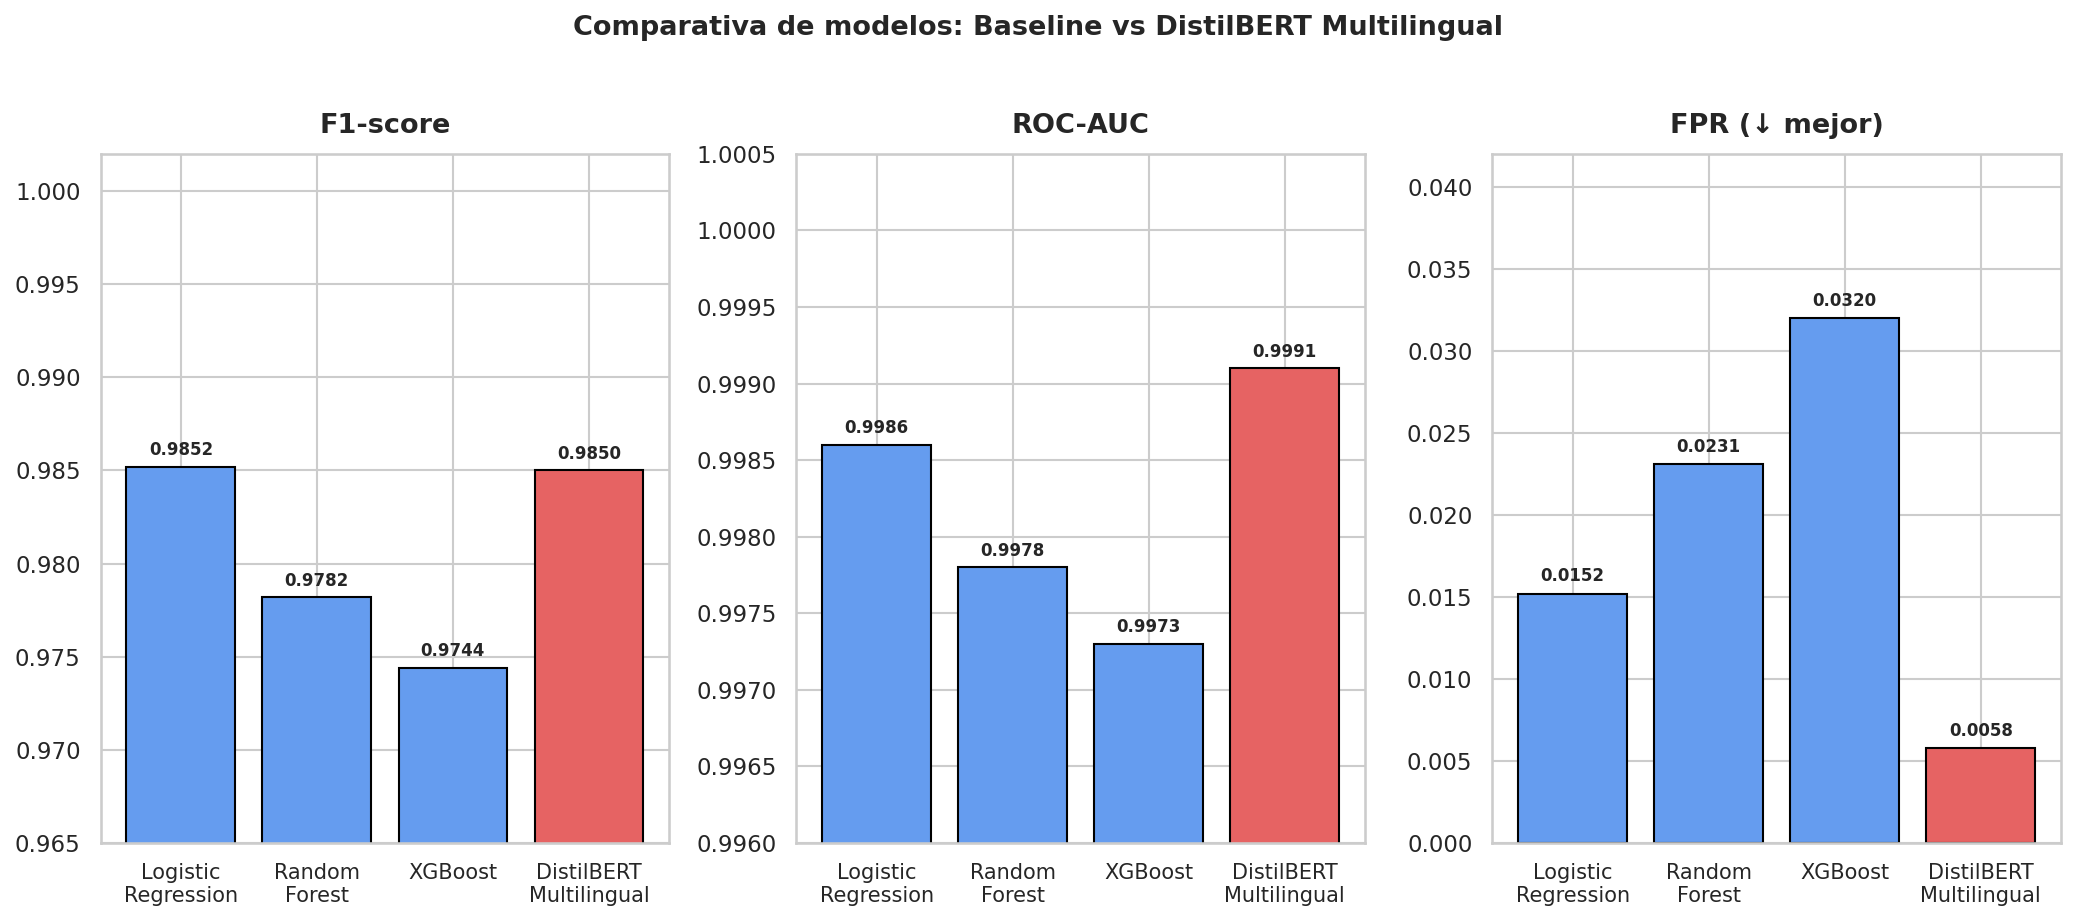

✓ Gráfico final guardado en Drive


In [35]:
import matplotlib.pyplot as plt
import numpy as np

nombres  = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'DistilBERT\nMultilingual']
f1s      = [0.9852, 0.9782, 0.9744, 0.9850]
aucs     = [0.9986, 0.9978, 0.9973, 0.9991]
fprs     = [0.0152, 0.0231, 0.0320, 0.0058]
colores  = ['#659CEF', '#659CEF', '#659CEF', '#E66363']

fig, axes = plt.subplots(1, 3, figsize=(14, 6), dpi=150)

# ── F1-score ───────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(range(len(nombres)), f1s, color=colores, edgecolor='black')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, fontsize=10)
ax.set_title('F1-score', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0.965, 1.002)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── ROC-AUC ────────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(range(len(nombres)), aucs, color=colores, edgecolor='black')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, fontsize=10)
ax.set_title('ROC-AUC', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0.9960, 1.0005)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.00005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── FPR ───────────────────────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(range(len(nombres)), fprs, color=colores, edgecolor='black')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, fontsize=10)
ax.set_title('FPR (↓ mejor)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0, 0.042)
for bar, val in zip(bars, fprs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Comparativa de modelos: Baseline vs DistilBERT Multilingual',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG_Phishing/comparativa_modelos_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico final guardado en Drive")

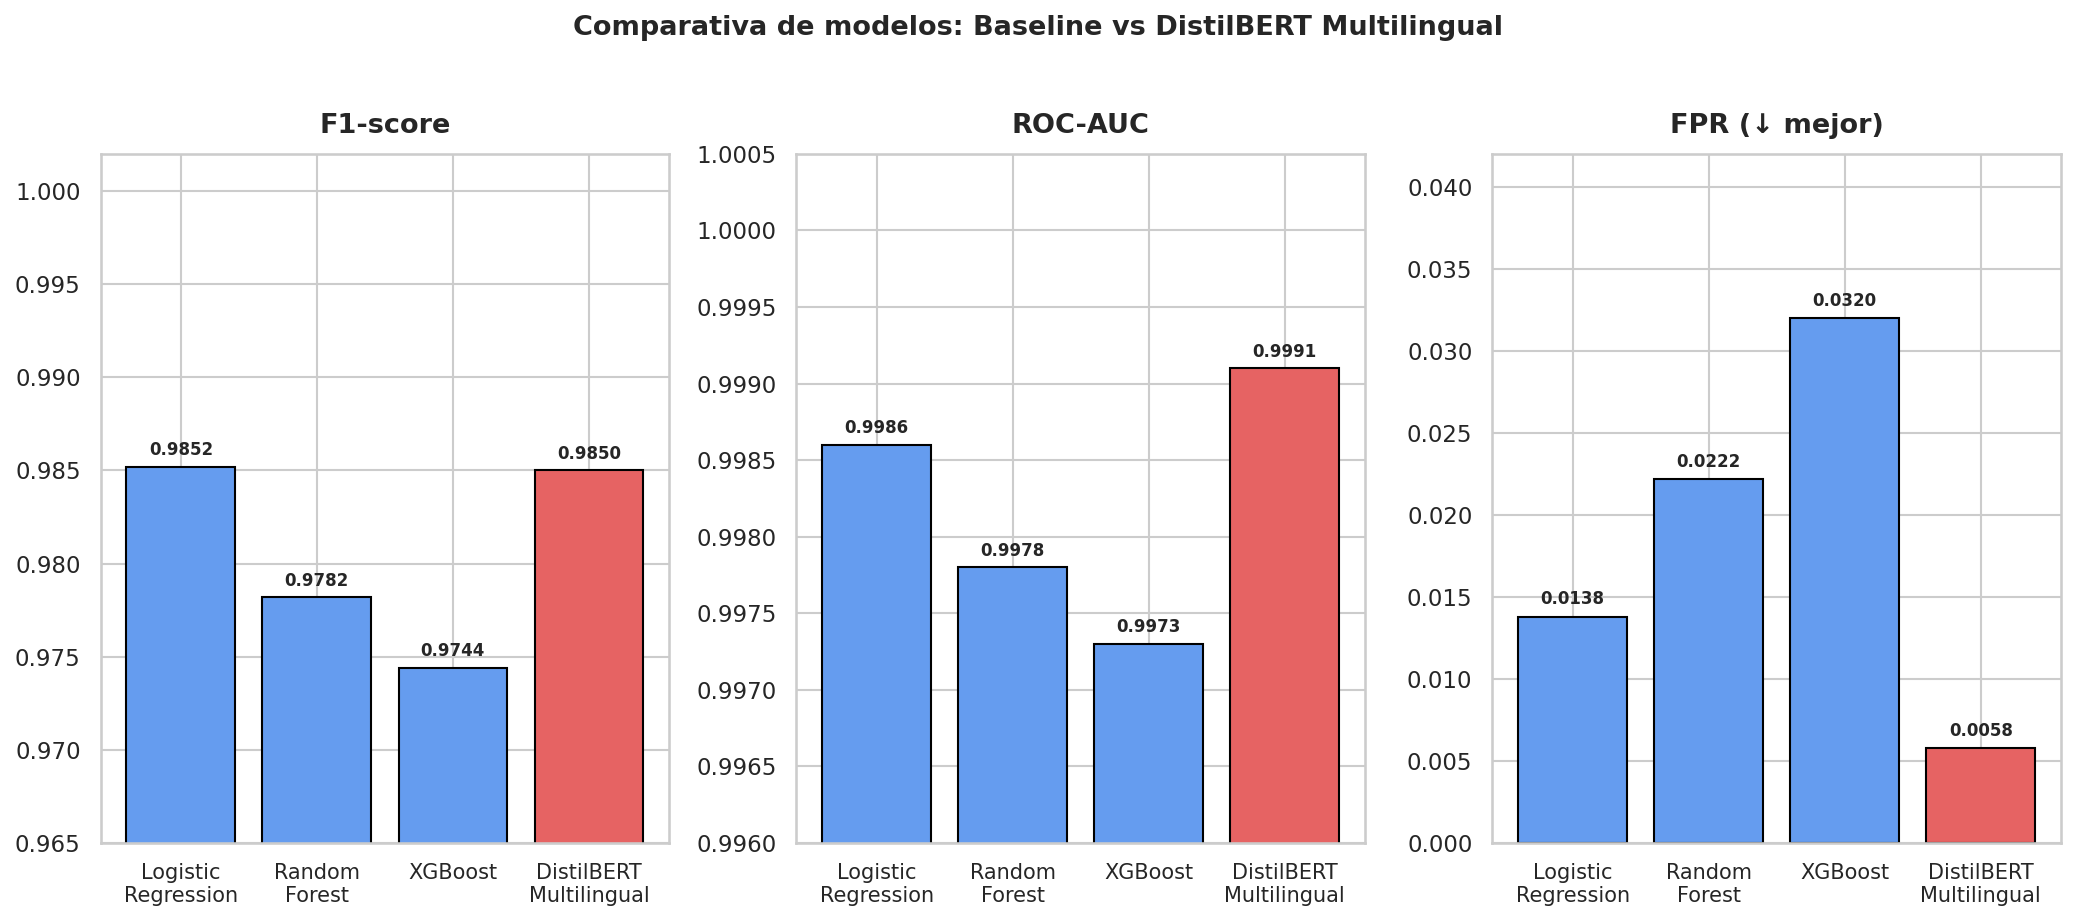

✓ Gráfico final guardado en Drive


In [42]:
import matplotlib.pyplot as plt
import numpy as np

nombres  = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'DistilBERT\nMultilingual']
f1s      = [0.9852, 0.9782, 0.9744, 0.9850]
aucs     = [0.9986, 0.9978, 0.9973, 0.9991]
fprs     = [0.0138, 0.0222, 0.0320, 0.0058]
colores  = ['#659CEF', '#659CEF', '#659CEF', '#E66363']

fig, axes = plt.subplots(1, 3, figsize=(14, 6), dpi=150)

# ── F1-score ───────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(range(len(nombres)), f1s, color=colores, edgecolor='black')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, fontsize=10)
ax.set_title('F1-score', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0.965, 1.002)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── ROC-AUC ────────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(range(len(nombres)), aucs, color=colores, edgecolor='black')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, fontsize=10)
ax.set_title('ROC-AUC', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0.9960, 1.0005)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.00005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── FPR ───────────────────────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(range(len(nombres)), fprs, color=colores, edgecolor='black')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, fontsize=10)
ax.set_title('FPR (↓ mejor)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0, 0.042)
for bar, val in zip(bars, fprs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Comparativa de modelos: Baseline vs DistilBERT Multilingual',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG_Phishing/comparativa_modelos_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico final guardado en Drive")

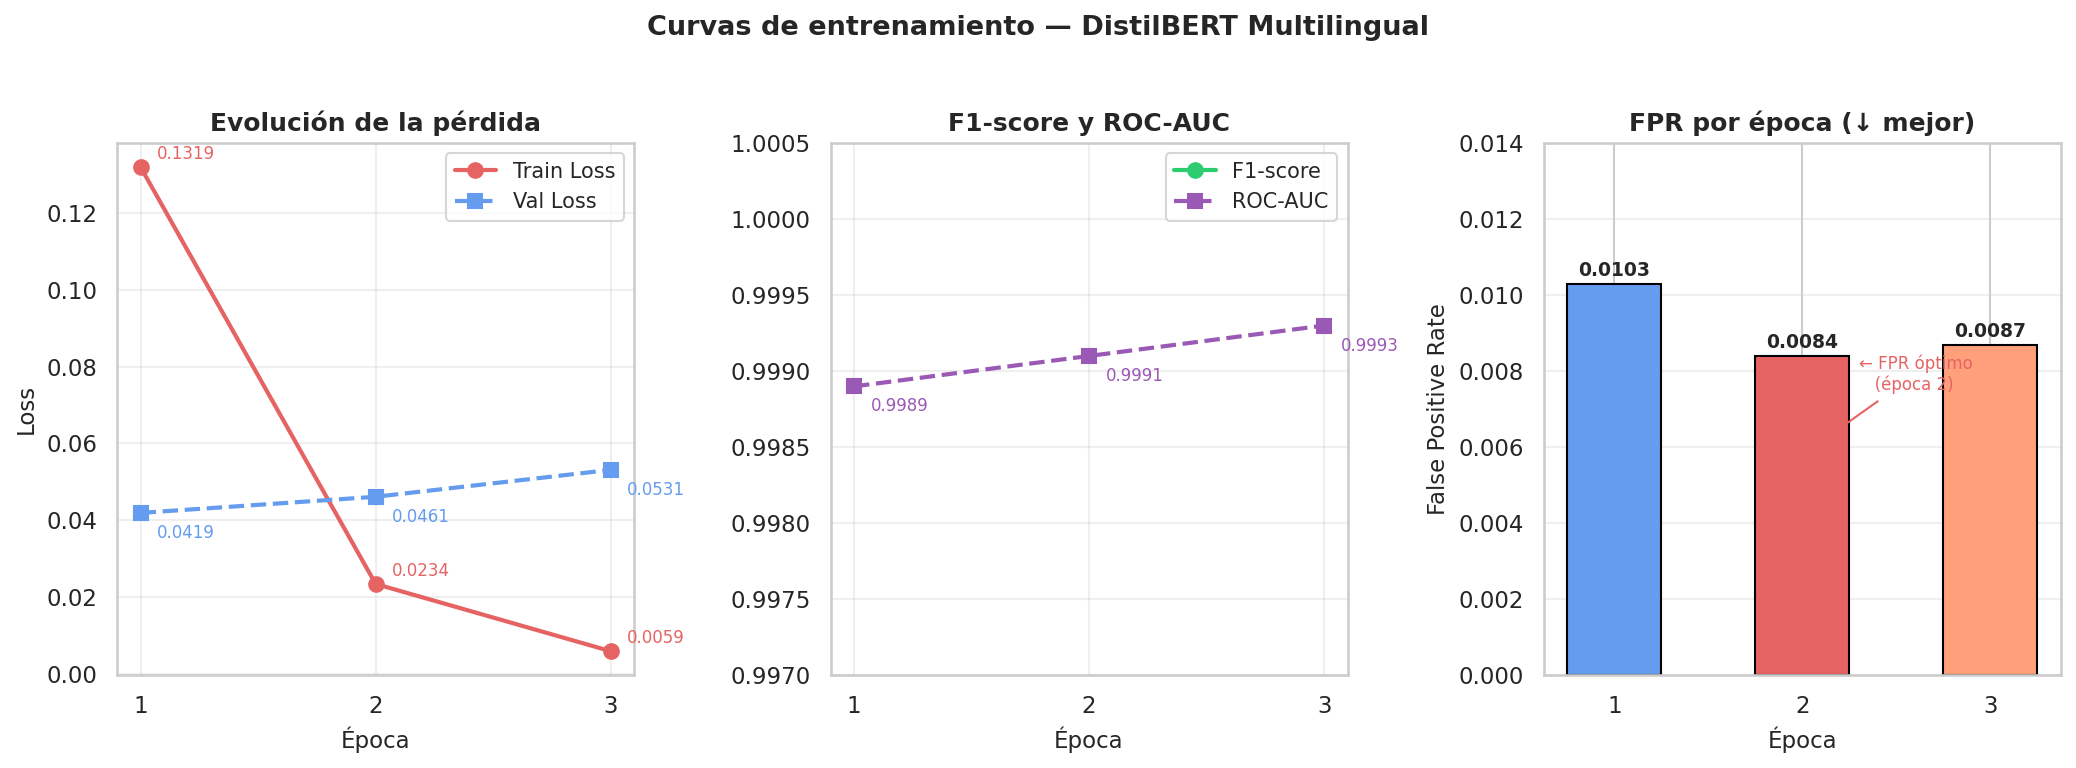

✓ Guardado: curvas_entrenamiento.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np

epocas      = [1, 2, 3]
train_loss  = [0.1319, 0.0234, 0.0059]
val_loss    = [0.0419, 0.0461, 0.0531]
f1          = [0.9856, 0.9880, 0.9884]
auc         = [0.9989, 0.9991, 0.9993]
fpr         = [0.0103, 0.0084, 0.0087]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=150)

# ── Loss ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epocas, train_loss, 'o-', color='#E66363', linewidth=2,
        markersize=7, label='Train Loss')
ax.plot(epocas, val_loss,   's--', color='#659CEF', linewidth=2,
        markersize=7, label='Val Loss')
for i, (tl, vl) in enumerate(zip(train_loss, val_loss)):
    ax.annotate(f'{tl:.4f}', (epocas[i], tl), textcoords='offset points',
                xytext=(8, 4), fontsize=8, color='#E66363')
    ax.annotate(f'{vl:.4f}', (epocas[i], vl), textcoords='offset points',
                xytext=(8, -12), fontsize=8, color='#659CEF')
ax.set_title('Evolución de la pérdida', fontsize=12, fontweight='bold')
ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_xticks(epocas)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── F1 y AUC ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epocas, f1,  'o-', color='#2ECC71', linewidth=2,
        markersize=7, label='F1-score')
ax.plot(epocas, auc, 's--', color='#9B59B6', linewidth=2,
        markersize=7, label='ROC-AUC')
for i, (f, a) in enumerate(zip(f1, auc)):
    ax.annotate(f'{f:.4f}', (epocas[i], f), textcoords='offset points',
                xytext=(8, 4), fontsize=8, color='#2ECC71')
    ax.annotate(f'{a:.4f}', (epocas[i], a), textcoords='offset points',
                xytext=(8, -12), fontsize=8, color='#9B59B6')
ax.set_title('F1-score y ROC-AUC', fontsize=12, fontweight='bold')
ax.set_xlabel('Época', fontsize=11)
ax.set_xticks(epocas)
ax.set_ylim(0.997, 1.0005)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── FPR ───────────────────────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(epocas, fpr, color=['#659CEF', '#E66363', '#FFA07A'],
              edgecolor='black', width=0.5)
for bar, val, ep in zip(bars, fpr, epocas):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
# Marcar época 2 como óptima
ax.annotate('← FPR óptimo\n   (época 2)',
            xy=(2, 0.0058), xytext=(2.3, 0.0075),
            fontsize=8, color='#E66363',
            arrowprops=dict(arrowstyle='->', color='#E66363'))
ax.set_title('FPR por época (↓ mejor)', fontsize=12, fontweight='bold')
ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('False Positive Rate', fontsize=11)
ax.set_xticks(epocas)
ax.set_ylim(0, 0.014)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Curvas de entrenamiento — DistilBERT Multilingual',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG_Phishing/curvas_entrenamiento.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: curvas_entrenamiento.png")

In [ ]:
!pip uninstall gradio gradio-client -y
!pip install huggingface_hub --upgrade --quiet
!pip install gradio --upgrade --quiet
!pip install lime --quiet
print("✓ Listo — reinicia el runtime ahora")

In [ ]:
import gradio
print(gradio.__version__)

In [ ]:
!pip install lime --quiet
print("✓ Listo")

In [38]:
from google.colab import drive
drive.mount('/content/drive')

import torch, re, email, io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from lime.lime_text import LimeTextExplainer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

CHECKPOINT_DIR = '/content/drive/MyDrive/TFG_Phishing/models_v2'
model_demo     = DistilBertForSequenceClassification.from_pretrained(
    f"{CHECKPOINT_DIR}/distilbert_fpr_optimo")
tokenizer_demo = DistilBertTokenizerFast.from_pretrained(
    f"{CHECKPOINT_DIR}/distilbert_fpr_optimo")
model_demo.to(device)
model_demo.eval()
print("✓ Modelo cargado")

explainer = LimeTextExplainer(class_names=['Legítimo', 'Phishing'], random_state=42)
print("✓ LIME listo")

def limpiar_html(texto):
    texto = re.sub(r'<[^>]+>', ' ', texto)
    for ent, rep in [('&nbsp;',' '),('&amp;','&'),('&lt;','<'),
                     ('&gt;','>'),('&quot;','"')]:
        texto = texto.replace(ent, rep)
    return re.sub(r'\s+', ' ', texto).strip()

def extraer_texto_archivo(ruta):
    if ruta is None:
        return None
    if ruta.lower().endswith('.eml'):
        with open(ruta, 'rb') as f:
            msg = email.message_from_bytes(f.read())
        asunto = msg.get('Subject', '')
        cuerpo = ''
        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == 'text/plain':
                    try:
                        cuerpo = part.get_payload(decode=True).decode(
                            part.get_content_charset() or 'utf-8', errors='replace')
                        break
                    except: continue
            if not cuerpo:
                for part in msg.walk():
                    if part.get_content_type() == 'text/html':
                        try:
                            cuerpo = limpiar_html(part.get_payload(decode=True).decode(
                                part.get_content_charset() or 'utf-8', errors='replace'))
                            break
                        except: continue
        else:
            raw = msg.get_payload(decode=True)
            if raw:
                raw = raw.decode(msg.get_content_charset() or 'utf-8', errors='replace')
                cuerpo = limpiar_html(raw) if '<html' in raw.lower() else raw
        return f"{asunto} {cuerpo}".strip()
    elif ruta.lower().endswith('.txt'):
        with open(ruta, 'r', encoding='utf-8', errors='replace') as f:
            return f.read().strip()
    return None

def predecir_proba_demo(textos):
    resultados = []
    for texto in textos:
        enc = tokenizer_demo(texto, truncation=True, padding='max_length',
                             max_length=256, return_tensors='pt')
        with torch.no_grad():
            logits = model_demo(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)).logits
        resultados.append(torch.softmax(logits, dim=1).cpu().numpy()[0])
    return np.array(resultados)

def analizar_correo(texto_manual, archivo):
    if archivo is not None:
        texto = extraer_texto_archivo(archivo)
        if not texto:
            return "No se pudo extraer texto del archivo.", None, ""
        fuente = f"Archivo: {archivo.split('/')[-1]}"
    elif texto_manual and len(texto_manual.strip()) >= 20:
        texto = texto_manual.strip()
        fuente = "Entrada manual"
    else:
        return "Introduzca el texto del correo o adjunte un archivo .eml/.txt", None, ""

    probs    = predecir_proba_demo([texto[:1000]])[0]
    es_phish = int(np.argmax(probs))
    conf     = probs[es_phish]
    etiqueta = f"PHISHING  —  Confianza: {conf:.1%}" if es_phish == 1 \
               else f"LEGÍTIMO  —  Confianza: {conf:.1%}"

    exp      = explainer.explain_instance(
        texto[:1000], predecir_proba_demo,
        num_features=10, num_samples=300, labels=[1])
    palabras = exp.as_list(label=1)
    terminos = [p[0] for p in palabras]
    pesos    = [p[1] for p in palabras]
    colores  = ['#C0392B' if p > 0 else '#2471A3' for p in pesos]

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.barh(range(len(terminos)), pesos, color=colores,
            edgecolor='#2C3E50', height=0.55, linewidth=0.6)
    ax.set_yticks(range(len(terminos)))
    ax.set_yticklabels(terminos, fontsize=11)
    ax.axvline(x=0, color='#2C3E50', linewidth=0.8)
    ax.set_xlabel('Contribución a la predicción (LIME)', fontsize=11)
    ax.set_title(f'Análisis de relevancia léxica\n{etiqueta}',
                 fontsize=12, fontweight='bold', pad=12)
    rojo = mpatches.Patch(color='#C0392B', label='Indicador de phishing')
    azul = mpatches.Patch(color='#2471A3', label='Indicador de legitimidad')
    ax.legend(handles=[rojo, azul], fontsize=9, loc='lower right',
              framealpha=0.9, edgecolor='#BDC3C7')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#BDC3C7')
    ax.spines['bottom'].set_color('#BDC3C7')
    ax.grid(True, axis='x', alpha=0.2, color='#BDC3C7')
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    buf.seek(0)

    preview = f"Fuente: {fuente}\n\n{texto[:400]}{'...' if len(texto)>400 else ''}"
    return etiqueta, Image.open(buf), preview

print("✓ Todo listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo: cuda


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ Modelo cargado
✓ LIME listo
✓ Todo listo


In [39]:
import gradio as gr

ejemplos = [
    ["Dear user, your account has been suspended. Verify your identity immediately: http://secure-paypal-verify.com"],
    ["Hi John, following up on the budget report from yesterday's meeting. Please send it when you get a chance. Thanks, Sarah"],
    ["Estimado cliente, su cuenta bancaria ha sido bloqueada. Verifique sus datos en: http://banco-seguro-es.net/verificar"],
]

with gr.Blocks(title="Detección de Phishing — TFG UA") as demo:
    gr.Markdown("""
    # Sistema Inteligente de Detección de Phishing en Correos Electrónicos
    ### Trabajo Fin de Grado · Grado en Ingeniería Informática · Universidad de Alicante
    **Autor:** José Manuel Martínez Giganto &nbsp;|&nbsp;
    **Tutora:** Dra. Patricia Compañ Rosique &nbsp;|&nbsp;
    **Modelo:** DistilBERT Multilingual · F1 = 0,9850 · AUC = 0,9991 · FPR = 0,0058
    ---
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Entrada")
            texto_input = gr.Textbox(
                label="Texto del correo electrónico",
                placeholder="Introduzca el contenido del correo...",
                lines=9
            )
            archivo_input = gr.File(
                label="O adjunte un archivo (.eml · .txt)",
                file_types=['.eml', '.txt']
            )
            btn = gr.Button("Analizar", variant="primary", size="lg")
            gr.Examples(
                examples=ejemplos,
                inputs=texto_input,
                label="Ejemplos de prueba"
            )

        with gr.Column(scale=1):
            gr.Markdown("### Resultado")
            resultado = gr.Textbox(
                label="Clasificación",
                lines=2,
                interactive=False
            )
            figura = gr.Image(label="Análisis de relevancia léxica (LIME)")
            preview = gr.Textbox(
                label="Texto analizado",
                lines=3,
                interactive=False
            )

    btn.click(
        fn=analizar_correo,
        inputs=[texto_input, archivo_input],
        outputs=[resultado, figura, preview]
    )

    gr.Markdown("""
    ---
    > **Nota metodológica:** Este sistema constituye una herramienta de apoyo a la decisión.
    > Una puntuación elevada de phishing indica la presencia de patrones lingüísticos
    > estadísticamente asociados a mensajes maliciosos, pero **el criterio definitivo
    > corresponde al usuario**. Se recomienda examinar el correo completo antes de
    > tomar cualquier acción.
    >
    > *Limitación conocida: el análisis se realiza exclusivamente sobre el contenido
    > textual. El examen de cabeceras técnicas (SPF, DKIM, DMARC) queda fuera del
    > alcance del sistema actual y constituye una línea de trabajo futuro.*
    """)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97cb35b46e62491ff3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
